In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

import datamapplot

/Users/tomasandrade/miniconda3/envs/datamapplot-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
root = '/Users/tomasandrade/Documents/BSC/ICHOIR/whale/experiments/whales_v1'

In [8]:
def make_ls_html(layer, simplify_name = False):
    input_file = f'{root}/feat_2d/feat_2d_layer_{layer}.csv'

    df = pd.read_csv(input_file, index_col=0)

    df_1 = df[['x', 'y', 'song']]

    if simplify_name:
        df_titles = df_1['song'].str.split('-', expand = True).copy()
        df_1['song_short'] = df_titles[0]
    
    ls_df = []
    for song in df_1['song'].unique():
        mask = df_1['song'] == song
        my_df = df_1[mask].copy()

        my_df = my_df.reset_index(drop=True)
        my_df['time'] = my_df.index.values*0.020
        my_df['time'] = my_df['time'].apply(lambda x: f"{int(x // 60):02d}:{x % 60:05.2f}")
        #my_df = my_df.drop(columns=['index'])
        ls_df.append(my_df)

    df_full = pd.concat(ls_df)

    df_full['label'] = df_full['song_short'] + ' | ' +  df_full['time']

    plot = datamapplot.create_interactive_plot(
                        df_full[['x', 'y']].values,
                        df_full['song'].values,
                        # arxivml_label_layers[2],
                        # arxivml_label_layers[4],
                        hover_text = df_full['label'].values,
                        font_family="Playfair Display SC",
                        enable_search=True
                        )
    
    experiment = root.split('/')[-1]
    out_html = f"{experiment}_ls_layer_{layer}.html"
    plot.save(out_html)

    return df_full

In [9]:
df_full = make_ls_html(12, simplify_name=True)

/var/folders/8k/_0xh01hd7y9bl_vjjlwxqtjr0000gn/T/ipykernel_1828/510695279.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1['song_short'] = df_titles[0]


In [10]:
df_full['song'].unique()

array(['sei-whale-balaenoptera-borealis',
       'north-atlantic-right-whale-eubalaena-glacialis-1',
       'killer-whale-orcinus-orca', 'pilot-whale-globicephala-spp',
       'blue-whale-balaenoptera-musculus',
       'northern-bottlenose-whale-hyperoodon-ampullatus',
       'north-atlantic-right-whale-eubalaena-glacialis-2',
       'humpback-whale-megaptera-novaeangliae',
       'fin-whale-balaenoptera physalus',
       'sperm-whale-physeter-macrocephalus',
       'minke-whale-balaenoptera-acutorostrata'], dtype=object)

In [11]:
from matplotlib.animation import FuncAnimation, PillowWriter

In [12]:
def make_animation(df_traj, df_background, name = 'whale'):

    # Assuming dfembed_song has 'x' and 'y'
    x = df_traj['x'].values
    y = df_traj['y'].values

    song_short = df_traj['song_short'].values[0]
    x_cm, y_cm = df_traj[['x', 'y']].mean()

    #phone_traj = df_phrase['phone_base'].values
    num_points = len(x)

    # Parameters
    fps = 20
    trail_length = 20
    head_size = 30
    trail_size = 5
    alpha_trail = 0.3

    # Set up 2D figure and axis
    fig, ax = plt.subplots(figsize=(10,6))

    # Clean up axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(False)

    
    ax.annotate(
    song_short,
    xy=(x_cm, y_cm),
    xytext=(x_cm, y_cm),  # Offset for the text position
    arrowprops=dict(arrowstyle="->", color='gray'),
    fontsize=22,
    fontweight='bold',
    color='black'
    )

    plt.tight_layout()

    for song in df_background['song'].unique():
        mask = df_background['song'] == song
        df_bckg = df_background[mask]
        ax.scatter(
            df_bckg['x'],
            df_bckg['y'],
            alpha= 0.25, #0.1,
            s = 0.1)#0.05)
        
    # Initialize trail, head and annotations
    trail_scatter, = ax.plot([], [], 'o', markersize=trail_size, alpha=alpha_trail, color='red')
    head_scatter, = ax.plot([], [], 'o', markersize=head_size / 5, color='red')

    def update(frame):
        start = max(0, frame - trail_length)
        trail_x = x[start:frame]
        trail_y = y[start:frame]

        trail_scatter.set_data(trail_x, trail_y)

        if frame < len(x):
            head_scatter.set_data([x[frame]], [y[frame]])
        else:
            head_scatter.set_data([], [])
            #annotation.set_text(phone_traj[frame])

        return trail_scatter, head_scatter

    # Animate
    #fps = 100
    interval = 1000/fps
    ani = FuncAnimation(fig, update, frames=num_points, interval=interval, blit=False)

    ani.save(f"animation_{name}.gif", writer=PillowWriter(fps=fps));

----- Working on song sei-whale-balaenoptera-borealis
----- Working on song north-atlantic-right-whale-eubalaena-glacialis-1
----- Working on song killer-whale-orcinus-orca
----- Working on song pilot-whale-globicephala-spp
----- Working on song blue-whale-balaenoptera-musculus
----- Working on song northern-bottlenose-whale-hyperoodon-ampullatus
----- Working on song north-atlantic-right-whale-eubalaena-glacialis-2
----- Working on song humpback-whale-megaptera-novaeangliae
----- Working on song fin-whale-balaenoptera physalus
----- Working on song sperm-whale-physeter-macrocephalus
----- Working on song minke-whale-balaenoptera-acutorostrata


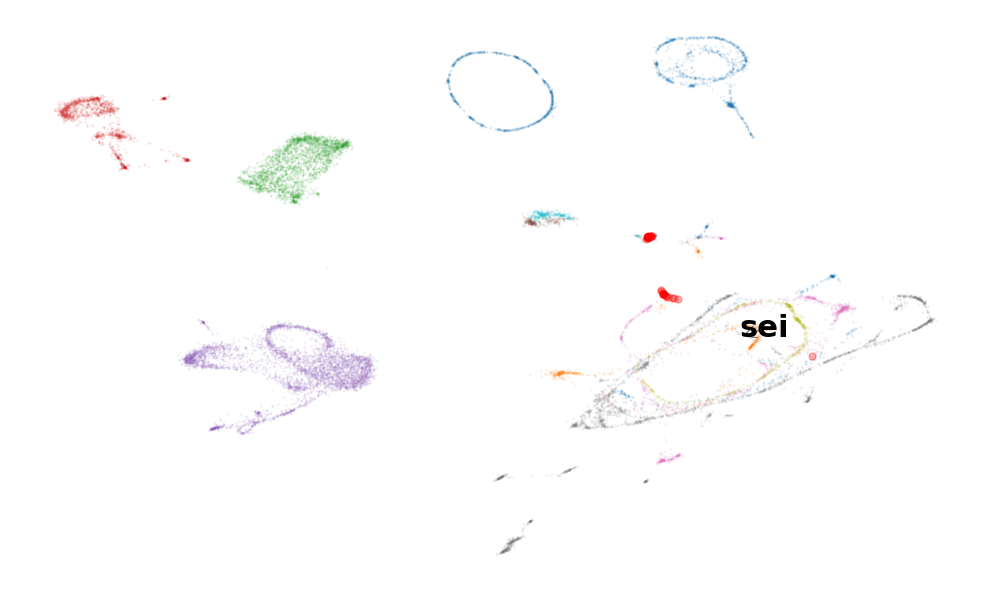

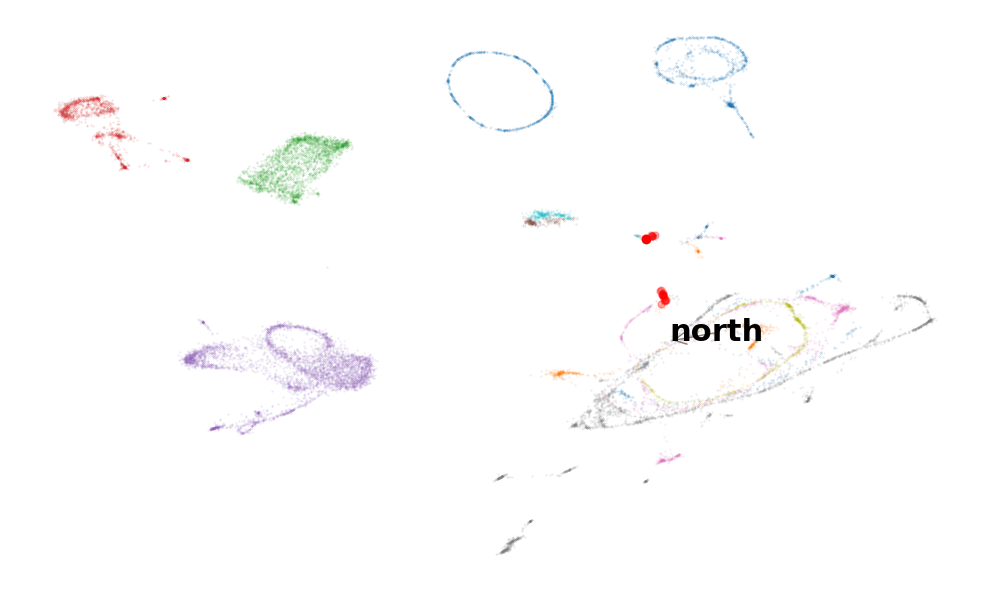

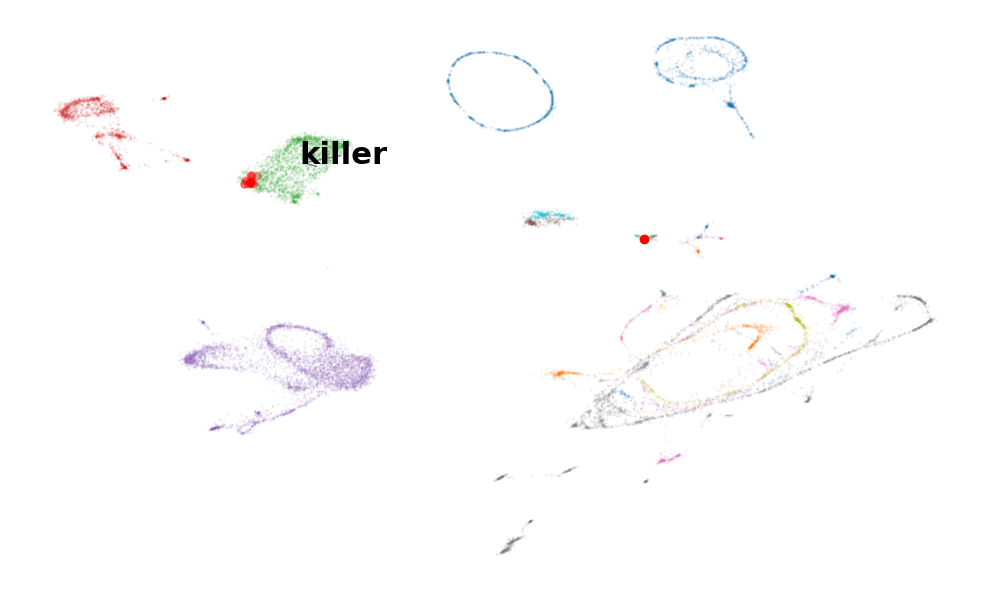

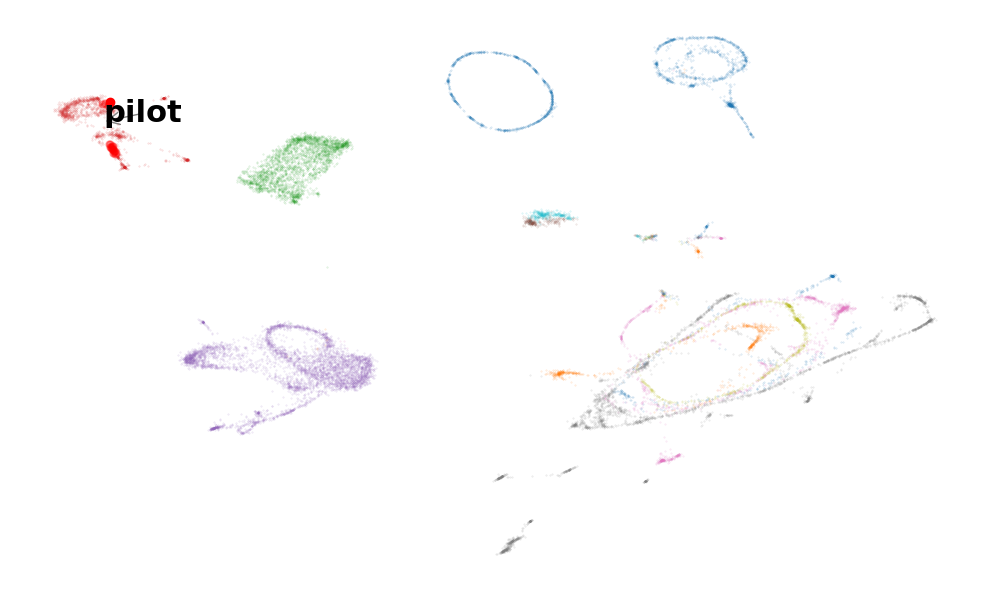

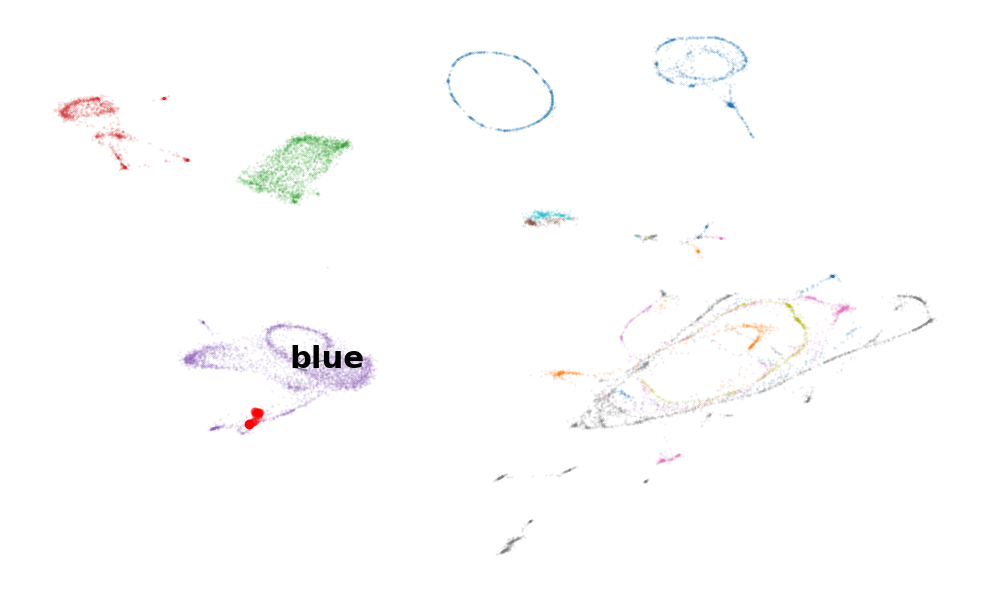

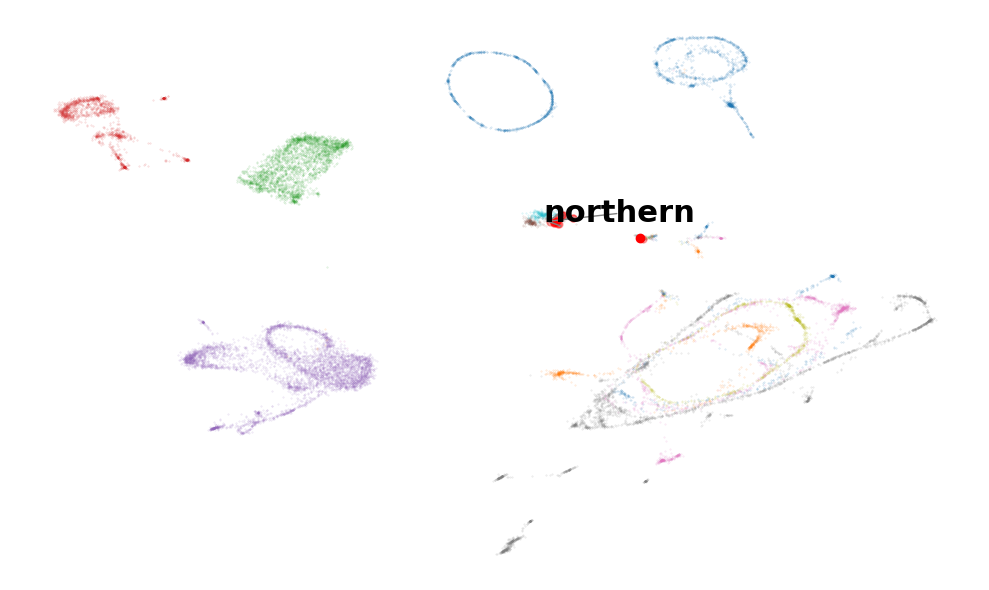

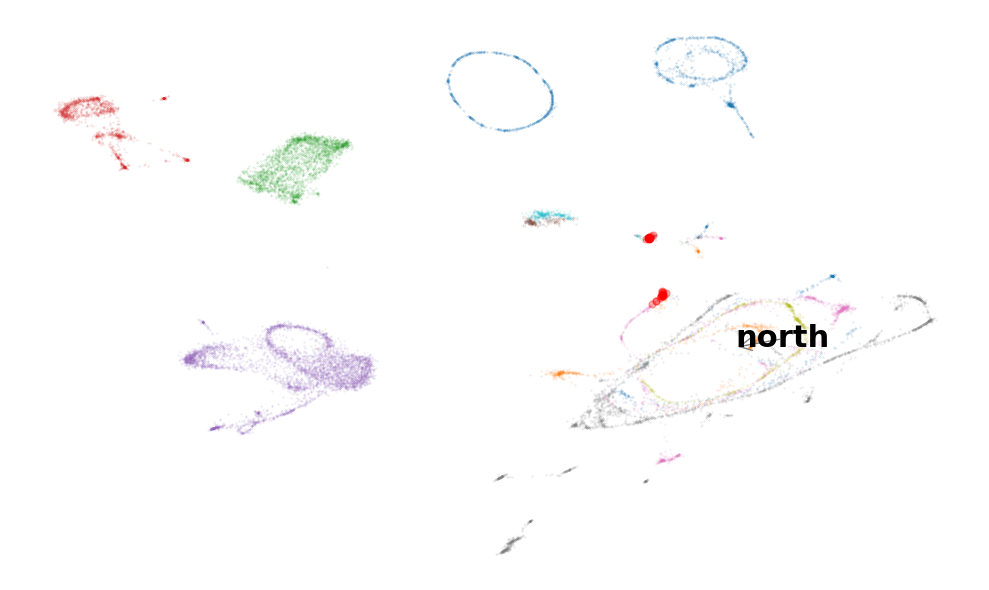

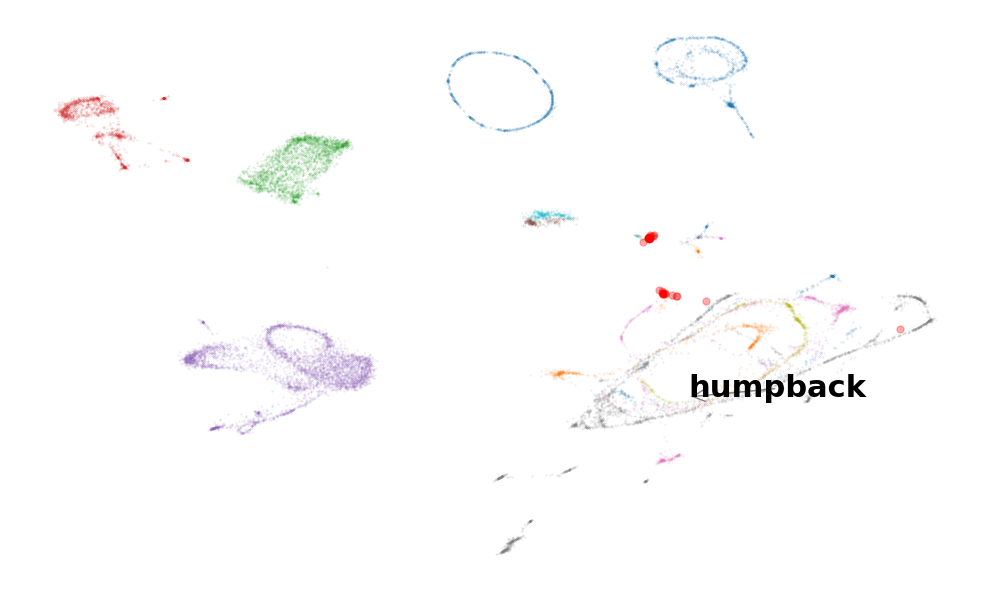

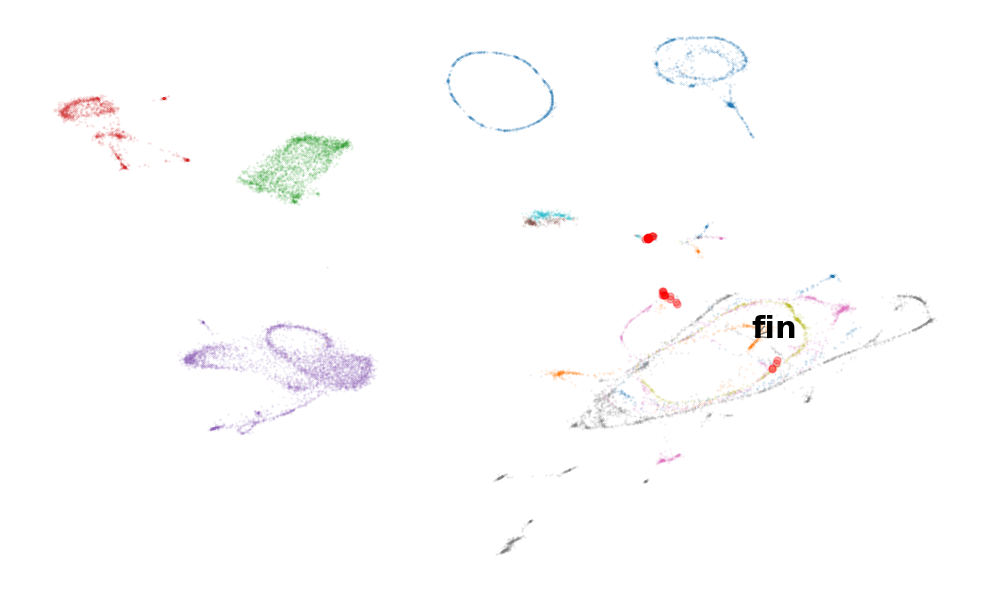

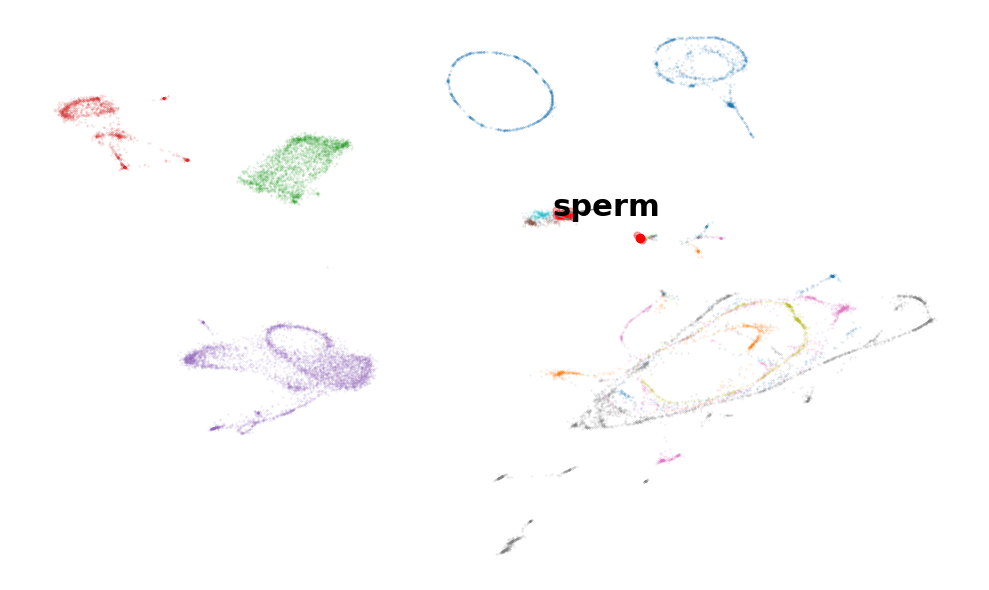

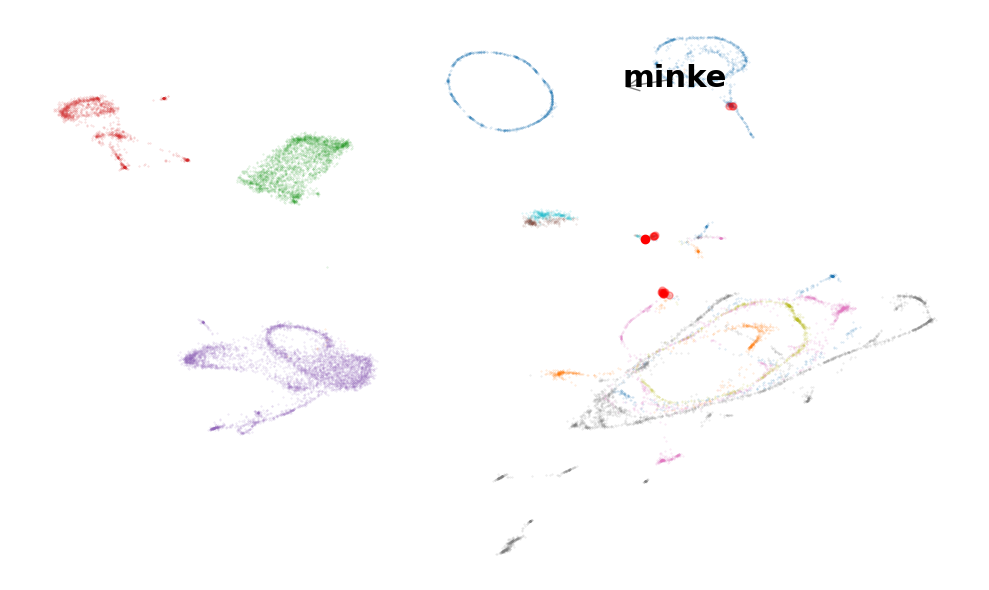

In [13]:
for song in list(df_full['song'].unique()):
    print(f'----- Working on song {song}')
    mask = df_full['song'] == song
    df_filter = df_full[mask]
    make_animation(df_filter, df_full, name=song)